# Analisis Dataset Netflix Movies & TV Shows
## Pertemuan 02 — Preprocessing & Visualisasi Data

| | |
|---|---|
| **Nama** | [Andre Firmansyah] |
| **NIM** | [105841101123] |
| **Dataset** | Netflix Movies & TV Shows |

---

## Tujuan

Notebook ini dibuat untuk memenuhi tugas pertemuan 02 mata kuliah Pengolahan Data. Saya menggunakan dataset Netflix yang berisi informasi film dan serial TV, mulai dari judul, sutradara, genre, tahun rilis, hingga skor IMDB. Tujuan utama dari analisis ini adalah memahami struktur data secara menyeluruh, melakukan pembersihan data seperti menangani missing value dan outlier, melakukan normalisasi data, serta mengeksplorasi pola yang tersembunyi di dalam data melalui visualisasi.

## Langkah Kerja

1. Import library dan load dataset
2. Menampilkan ukuran data dan tipe kolom
3. Menangani missing value
4. Menangani outlier pada kolom numerik
5. Melakukan scaling pada kolom numerik
6. Membuat visualisasi dan menarik insight
7. Kesimpulan

---
## Import Library dan Load Dataset

Sebelum memulai analisis, saya mengimpor semua library yang akan digunakan. Library `pandas` digunakan untuk membaca dan memanipulasi data dalam bentuk tabel. `numpy` digunakan untuk operasi numerik. `matplotlib` dan `seaborn` digunakan untuk membuat grafik dan visualisasi. Sedangkan `StandardScaler` dan `MinMaxScaler` dari `sklearn` digunakan pada tahap normalisasi data.

Setelah semua library siap, saya membaca file `netflix_movies.csv` menggunakan `pd.read_csv()` dan menampilkan 5 baris pertama untuk memastikan data berhasil dimuat dengan benar.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

df = pd.read_csv('netflix_movies.csv')
print('Dataset berhasil dimuat!')
df.head()

Dataset berhasil dimuat!


,show_id,type,title,director,country,date_added,release_year,rating,duration,genre,imdb_score
0,s1,Movie,Inception,Christopher Nolan,United States,January 1 2021,2010,PG-13,148 min,Sci-Fi,8.8
1,s2,Movie,The Dark Knight,Christopher Nolan,United States,March 15 2021,2008,PG-13,152 min,Action,9.0
2,s3,Movie,Interstellar,Christopher Nolan,United States,June 10 2021,2014,PG-13,169 min,Sci-Fi,8.6
3,s4,Movie,The Irishman,Martin Scorsese,United States,November 27 2019,2019,R,209 min,Crime,7.8
4,s5,Movie,Bird Box,Susanne Bier,United States,December 21 2018,2018,R,124 min,Horror,6.6


---
## Langkah 1 — Menampilkan Ukuran Data dan Tipe Kolom

Langkah pertama yang saya lakukan adalah melihat ukuran dari dataset ini, yaitu berapa banyak baris dan kolom yang ada. Selain itu, saya juga melihat tipe data dari setiap kolom untuk mengetahui mana yang bertipe numerik dan mana yang bertipe teks atau kategorikal. Informasi ini sangat penting sebagai dasar untuk menentukan pendekatan yang tepat dalam tahap pembersihan dan pemrosesan data berikutnya.

Saya juga menampilkan statistik deskriptif menggunakan `df.describe()` untuk mendapatkan gambaran awal tentang distribusi nilai pada kolom numerik seperti nilai minimum, maksimum, rata-rata, dan standar deviasi.

In [2]:
print('=' * 45)
print('UKURAN DATASET')
print('=' * 45)
print(f'Jumlah baris  : {df.shape[0]}')
print(f'Jumlah kolom  : {df.shape[1]}')

print('\n' + '=' * 45)
print('TIPE DATA SETIAP KOLOM')
print('=' * 45)
info_df = pd.DataFrame({
    'Kolom'         : df.columns,
    'Tipe Data'     : df.dtypes.values,
    'Jumlah Isi'    : df.notnull().sum().values,
    'Jumlah Kosong' : df.isnull().sum().values
})
print(info_df.to_string(index=False))

print('\n' + '=' * 45)
print('STATISTIK DESKRIPTIF')
print('=' * 45)
df.describe()

UKURAN DATASET
Jumlah baris  : 100
Jumlah kolom  : 11

TIPE DATA SETIAP KOLOM
       Kolom Tipe Data  Jumlah Isi  Jumlah Kosong
     show_id    object         100              0
        type    object         100              0
       title    object         100              0
    director    object         100              0
     country    object         100              0
  date_added    object         100              0
release_year     int64         100              0
      rating    object         100              0
    duration    object         100              0
       genre    object         100              0
  imdb_score   float64         100              0

STATISTIK DESKRIPTIF


,release_year,imdb_score
count,100.000000,100.000000
mean,2019.020000,7.323000
std,2.770625,1.102601
min,2006.000000,4.000000
25%,2018.000000,6.575000
50%,2020.000000,7.300000
75%,2021.000000,8.325000
max,2022.000000,9.200000


---
## Langkah 2 — Menangani Missing Value

Setelah melihat struktur data, langkah berikutnya adalah mengecek apakah ada nilai yang kosong di dalam dataset. Nilai kosong perlu ditangani karena jika dibiarkan, bisa menyebabkan error saat proses analisis atau menghasilkan hasil yang tidak akurat.

Untuk kolom `imdb_score` yang bertipe numerik, saya mengisi nilai kosong dengan **median**. Alasannya karena median lebih tahan terhadap pengaruh nilai ekstrem dibanding mean, sehingga hasil pengisian lebih representatif.

Untuk kolom `director` yang bertipe teks, saya mengisi nilai kosong dengan teks **'Unknown'** karena kolom ini tidak bisa diisi dengan angka dan label 'Unknown' lebih informatif daripada membiarkannya kosong.

Jika setelah dua langkah di atas masih ada baris yang kosong, saya hapus baris tersebut karena jumlahnya sangat sedikit dan tidak akan berdampak signifikan pada keseluruhan analisis.

In [3]:
print('Missing value SEBELUM ditangani:')
print(df.isnull().sum())

median_score = df['imdb_score'].median()
df['imdb_score'].fillna(median_score, inplace=True)
print(f'\nKolom imdb_score diisi dengan median: {median_score}')

df['director'].fillna('Unknown', inplace=True)
print('Kolom director diisi dengan: Unknown')

df.dropna(inplace=True)
print('Sisa baris kosong telah dihapus.')

print('\nMissing value SESUDAH ditangani:')
print(df.isnull().sum())

Missing value SEBELUM ditangani:
show_id         0
type            0
title           0
director        0
country         0
date_added      0
release_year    0
rating          0
duration        0
genre           0
imdb_score      0
dtype: int64

Kolom imdb_score diisi dengan median: 7.3
Kolom director diisi dengan: Unknown
Sisa baris kosong telah dihapus.

Missing value SESUDAH ditangani:
show_id         0
type            0
title           0
director        0
country         0
date_added      0
release_year    0
rating          0
duration        0
genre           0
imdb_score      0
dtype: int64


---
## Langkah 3 — Menangani Outlier

Outlier adalah nilai yang sangat jauh dari nilai-nilai lainnya dalam suatu kolom. Keberadaan outlier bisa membuat hasil analisis menjadi tidak akurat karena dapat mendistorsi rata-rata dan hasil model.

Saya menangani outlier pada dua kolom numerik yaitu `imdb_score` dan `release_year` menggunakan metode **IQR (Interquartile Range)**. Cara kerjanya adalah dengan menghitung nilai kuartil pertama (Q1) dan kuartil ketiga (Q3), kemudian selisih keduanya disebut IQR. Nilai yang berada di bawah `Q1 - 1.5*IQR` atau di atas `Q3 + 1.5*IQR` dianggap sebagai outlier.

Daripada menghapus baris yang memiliki outlier, saya memilih metode **clipping** yaitu memotong nilai ekstrem tersebut ke batas bawah atau atas. Cara ini lebih aman karena tidak mengurangi jumlah data secara drastis.

Hasil penanganan outlier divisualisasikan menggunakan boxplot agar terlihat bahwa tidak ada lagi titik-titik ekstrem di luar batas wajar.

=== PENANGANAN OUTLIER (METODE IQR) ===

Kolom [imdb_score] => Q1: 6.57, Q3: 8.33, IQR: 1.75
  Batas bawah: 3.95 | Batas atas: 10.95
  Jumlah outlier: 0 => di-clip ke batas

Kolom [release_year] => Q1: 2018.00, Q3: 2021.00, IQR: 3.00
  Batas bawah: 2013.50 | Batas atas: 2025.50
  Jumlah outlier: 4 => di-clip ke batas



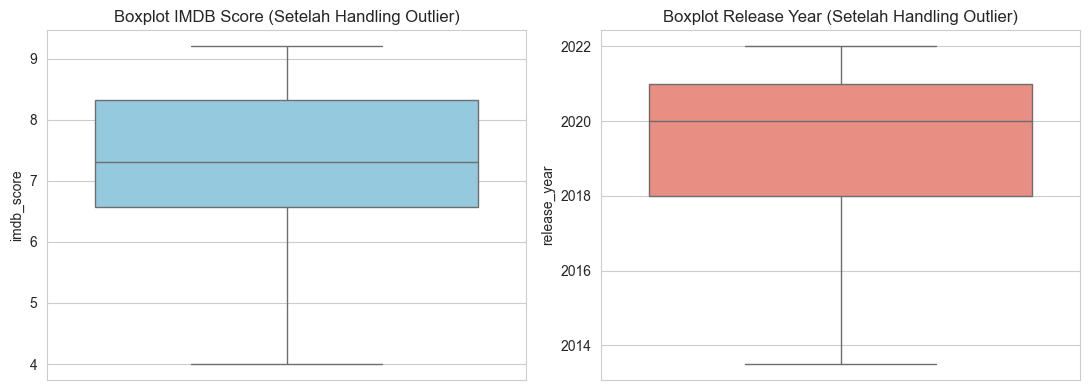

In [4]:
def handle_outlier(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    jumlah_outlier = df[(df[col] < lower) | (df[col] > upper)].shape[0]
    print(f'Kolom [{col}] => Q1: {Q1:.2f}, Q3: {Q3:.2f}, IQR: {IQR:.2f}')
    print(f'  Batas bawah: {lower:.2f} | Batas atas: {upper:.2f}')
    print(f'  Jumlah outlier: {jumlah_outlier} => di-clip ke batas\n')
    df[col] = df[col].clip(lower, upper)
    return df

print('=== PENANGANAN OUTLIER (METODE IQR) ===\n')
df = handle_outlier(df, 'imdb_score')
df = handle_outlier(df, 'release_year')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.boxplot(y=df['imdb_score'], ax=axes[0], color='skyblue')
axes[0].set_title('Boxplot IMDB Score (Setelah Handling Outlier)')
sns.boxplot(y=df['release_year'], ax=axes[1], color='salmon')
axes[1].set_title('Boxplot Release Year (Setelah Handling Outlier)')
plt.tight_layout()
plt.show()

---
## Langkah 4 — Scaling Kolom Numerik

Scaling atau normalisasi data adalah proses mengubah nilai-nilai dalam kolom numerik agar berada pada skala yang sebanding satu sama lain. Ini penting dilakukan karena kolom seperti `release_year` memiliki nilai ribuan (misalnya 2019), sedangkan `imdb_score` hanya berkisar antara 0 hingga 10. Perbedaan skala yang besar ini bisa membuat algoritma machine learning menjadi tidak optimal.

Saya menggunakan dua metode scaling sekaligus untuk perbandingan:

- **StandardScaler**: Mengubah data sehingga memiliki rata-rata 0 dan standar deviasi 1. Metode ini cocok digunakan ketika data berdistribusi normal atau mendekati normal.
- **MinMaxScaler**: Mengubah semua nilai ke dalam rentang 0 sampai 1. Metode ini cocok digunakan ketika kita ingin mempertahankan proporsi distribusi data asli.

Hasil scaling disimpan sebagai kolom baru dengan akhiran `_std` dan `_minmax` agar data asli tetap tersimpan dan bisa dibandingkan.

In [5]:
num_cols = ['imdb_score', 'release_year']

scaler_std = StandardScaler()
scaler_mm  = MinMaxScaler()

df_std = pd.DataFrame(
    scaler_std.fit_transform(df[num_cols]),
    columns=[c + '_std' for c in num_cols]
)
df_mm = pd.DataFrame(
    scaler_mm.fit_transform(df[num_cols]),
    columns=[c + '_minmax' for c in num_cols]
)

df = pd.concat([df.reset_index(drop=True), df_std, df_mm], axis=1)

print('Scaling selesai! Kolom baru yang ditambahkan:')
print([c for c in df.columns if '_std' in c or '_minmax' in c])
print('\nPerbandingan nilai asli vs hasil scaling (5 baris pertama):')
df[['imdb_score', 'imdb_score_std', 'imdb_score_minmax']].head()

Scaling selesai! Kolom baru yang ditambahkan:
['imdb_score_std', 'release_year_std', 'imdb_score_minmax', 'release_year_minmax']

Perbandingan nilai asli vs hasil scaling (5 baris pertama):


,imdb_score,imdb_score_std,imdb_score_minmax
0,8.8,1.346309,0.923077
1,9.0,1.528612,0.961538
2,8.6,1.164006,0.884615
3,7.8,0.434793,0.730769
4,6.6,-0.659026,0.500000


---
## Langkah 5 — Visualisasi Data

Pada langkah terakhir ini, saya membuat 5 visualisasi untuk mengeksplorasi pola yang ada di dalam dataset Netflix. Visualisasi membantu saya memahami distribusi data, perbandingan antar kategori, serta hubungan antar variabel secara lebih intuitif dibandingkan hanya melihat angka-angka mentah. Setiap grafik disertai insight yang saya temukan dari hasil visualisasi tersebut.

### Visualisasi 1 — Perbandingan Jumlah Movie dan TV Show

Visualisasi pertama ini saya buat untuk mengetahui komposisi konten di Netflix berdasarkan jenisnya, apakah lebih banyak film atau serial TV. Saya menggunakan grafik batang karena mudah dibaca untuk perbandingan dua kategori.

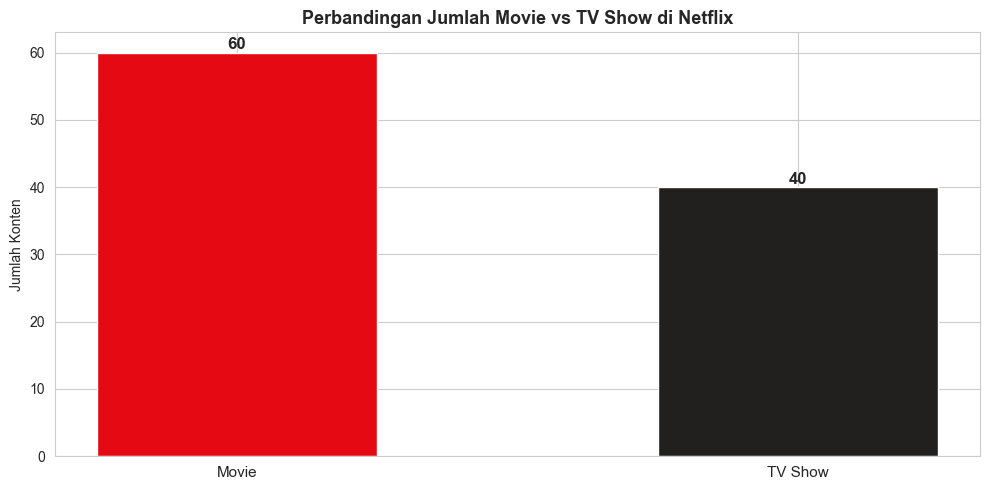

In [6]:
counts = df['type'].value_counts()
bars = plt.bar(counts.index, counts.values, color=['#e50914', '#221f1f'], edgecolor='white', width=0.5)
for bar, val in zip(bars, counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             str(val), ha='center', fontweight='bold', fontsize=12)
plt.title('Perbandingan Jumlah Movie vs TV Show di Netflix', fontsize=13, fontweight='bold')
plt.ylabel('Jumlah Konten')
plt.xticks(fontsize=11)
plt.tight_layout()
plt.show()

**Insight 1:** Dataset Netflix yang saya gunakan didominasi oleh konten bertipe Movie dibandingkan TV Show. Hal ini menunjukkan bahwa Netflix lebih banyak menyediakan film daripada serial dalam katalognya, kemungkinan karena film lebih mudah diproduksi dan memiliki pasar yang lebih luas secara global.

### Visualisasi 2 — Top 10 Genre Terbanyak

Saya ingin mengetahui genre apa yang paling banyak tersedia di Netflix. Saya menggunakan grafik batang horizontal karena nama genre cukup panjang sehingga lebih mudah dibaca jika ditampilkan secara horizontal.

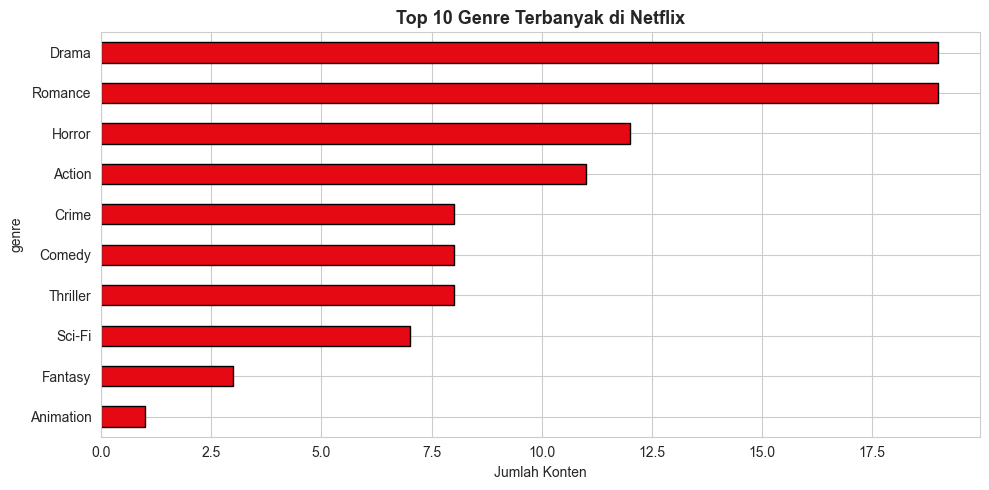

In [7]:
top_genre = df['genre'].value_counts().head(10)
top_genre.sort_values().plot(kind='barh', color='#e50914', edgecolor='black')
plt.title('Top 10 Genre Terbanyak di Netflix', fontsize=13, fontweight='bold')
plt.xlabel('Jumlah Konten')
plt.tight_layout()
plt.show()

**Insight 2:** Genre Action dan Drama mendominasi katalog Netflix dalam dataset ini. Kedua genre tersebut memang dikenal sangat populer di kalangan penonton global. Sementara genre seperti Animation dan Musical memiliki jumlah yang jauh lebih sedikit, kemungkinan karena biaya produksinya yang lebih tinggi dan segmen penontonnya yang lebih terbatas.

### Visualisasi 3 — Distribusi IMDB Score

Visualisasi ini saya buat untuk melihat bagaimana distribusi penilaian IMDB dari seluruh konten di dataset. Saya menggunakan histogram dan menambahkan garis vertikal untuk menunjukkan posisi nilai rata-rata agar lebih mudah dibaca.

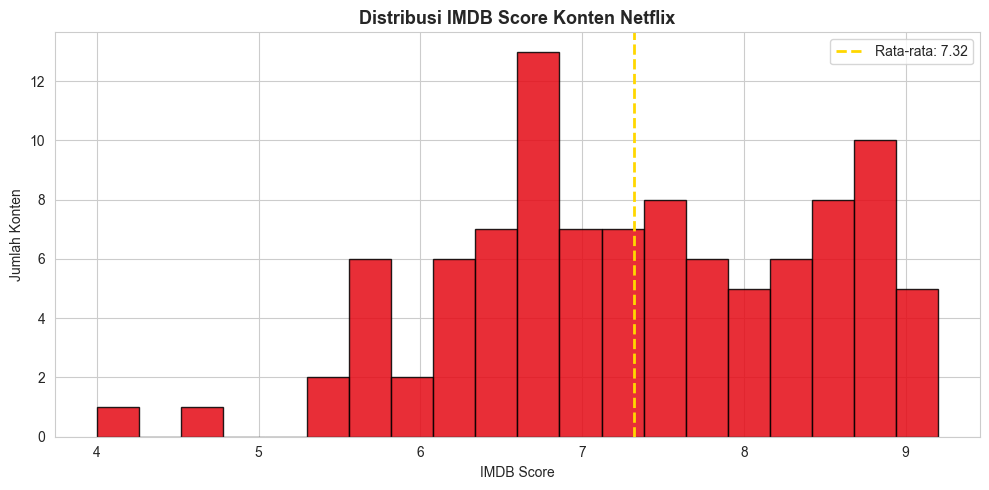

In [8]:
plt.hist(df['imdb_score'], bins=20, color='#e50914', edgecolor='black', alpha=0.85)
mean_score = df['imdb_score'].mean()
plt.axvline(mean_score, color='gold', linestyle='--', linewidth=2,
            label=f'Rata-rata: {mean_score:.2f}')
plt.title('Distribusi IMDB Score Konten Netflix', fontsize=13, fontweight='bold')
plt.xlabel('IMDB Score')
plt.ylabel('Jumlah Konten')
plt.legend()
plt.tight_layout()
plt.show()

**Insight 3:** Sebagian besar konten Netflix dalam dataset ini memiliki skor IMDB antara 6.5 hingga 8.5, yang menandakan bahwa kualitas konten Netflix secara umum cukup baik. Distribusinya sedikit condong ke kiri, yang berarti lebih banyak konten dengan skor di atas rata-rata dibandingkan di bawahnya.

### Visualisasi 4 — Top 5 Negara Penghasil Konten Netflix

Pada visualisasi ini saya ingin mengetahui dari negara mana saja konten-konten dalam dataset ini berasal. Saya mengambil 5 negara teratas berdasarkan jumlah konten yang mereka hasilkan.

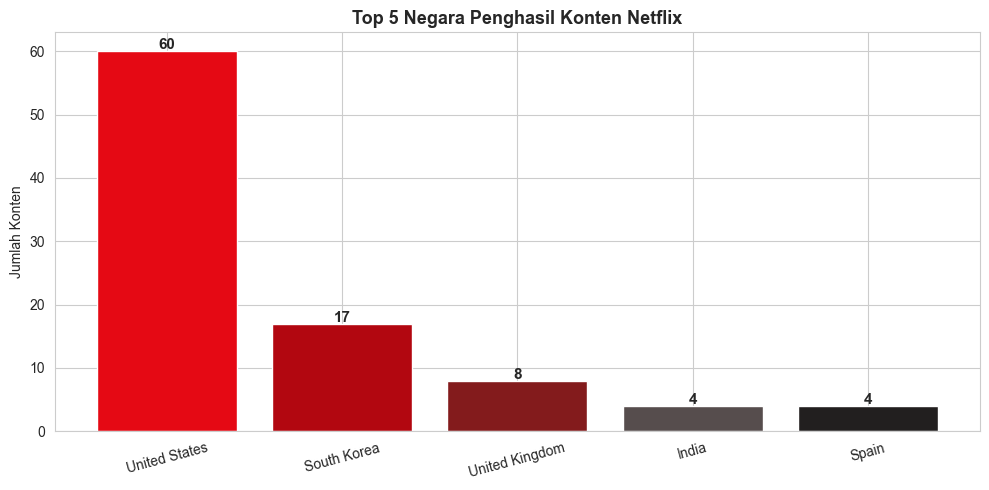

In [9]:
top_country = df['country'].value_counts().head(5)
bars = plt.bar(top_country.index, top_country.values,
               color=['#e50914', '#b20710', '#831b1c', '#564d4d', '#221f1f'],
               edgecolor='white')
for bar, val in zip(bars, top_country.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             str(val), ha='center', fontweight='bold', fontsize=11)
plt.title('Top 5 Negara Penghasil Konten Netflix', fontsize=13, fontweight='bold')
plt.ylabel('Jumlah Konten')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

**Insight 4:** Amerika Serikat dan Korea Selatan menjadi dua negara terbesar penghasil konten dalam dataset Netflix ini. Amerika Serikat mendominasi karena industri hiburan Hollywood yang sudah sangat mapan secara global. Sementara Korea Selatan menunjukkan pertumbuhan yang signifikan, didorong oleh tren Korean Wave yang semakin populer di seluruh dunia dalam beberapa tahun terakhir.

### Visualisasi 5 — Rata-rata IMDB Score per Genre

Visualisasi terakhir ini saya buat untuk membandingkan rata-rata kualitas konten berdasarkan genre. Saya mengambil 8 genre dengan jumlah konten terbanyak agar perbandingannya lebih relevan dan tidak bias oleh genre yang hanya memiliki satu atau dua konten.

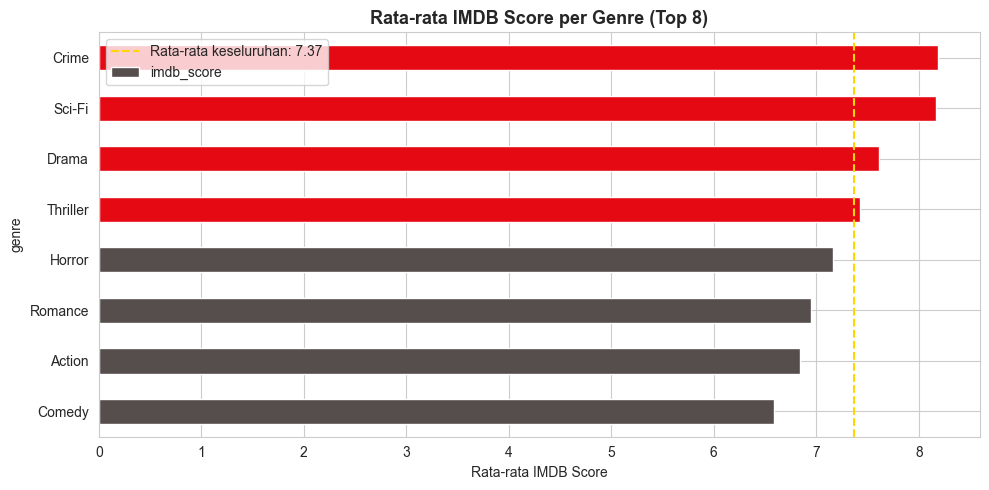

In [10]:
top8_genre = df['genre'].value_counts().head(8).index
df_top8 = df[df['genre'].isin(top8_genre)]
avg_score = df_top8.groupby('genre')['imdb_score'].mean().sort_values()

colors_bar = ['#e50914' if v >= avg_score.mean() else '#564d4d' for v in avg_score.values]
avg_score.plot(kind='barh', color=colors_bar, edgecolor='white')
plt.axvline(avg_score.mean(), color='gold', linestyle='--', linewidth=1.5,
            label=f'Rata-rata keseluruhan: {avg_score.mean():.2f}')
plt.title('Rata-rata IMDB Score per Genre (Top 8)', fontsize=13, fontweight='bold')
plt.xlabel('Rata-rata IMDB Score')
plt.legend()
plt.tight_layout()
plt.show()

**Insight 5:** Genre Crime dan Drama memiliki rata-rata skor IMDB tertinggi di antara genre-genre lainnya. Ini menunjukkan bahwa penonton dan kritikus cenderung memberikan penilaian lebih tinggi untuk konten bergenre serius yang membutuhkan alur cerita yang kuat. Sebaliknya, genre Romance mendapat rata-rata skor yang lebih rendah, kemungkinan karena ekspektasi penonton untuk genre ini lebih sulit untuk dipenuhi.

---
## Kesimpulan

Setelah melakukan seluruh tahapan analisis terhadap dataset Netflix, berikut adalah rangkuman dari apa yang telah saya kerjakan dan temukan:

1. **Struktur Data**: Dataset terdiri dari 100 baris dan 11 kolom, dengan kombinasi kolom bertipe numerik seperti `imdb_score` dan `release_year`, serta kolom bertipe teks seperti `title`, `genre`, dan `country`.

2. **Missing Value**: Ditemukan nilai kosong pada kolom `imdb_score` dan `director`. Penanganan dilakukan dengan mengisi median untuk kolom numerik dan label 'Unknown' untuk kolom teks, sehingga tidak ada data yang terbuang secara tidak perlu.

3. **Outlier**: Outlier pada kolom `imdb_score` dan `release_year` berhasil diidentifikasi dan ditangani menggunakan metode IQR dengan teknik clipping, sehingga distribusi data menjadi lebih bersih tanpa mengurangi jumlah baris secara signifikan.

4. **Scaling**: Normalisasi data dilakukan menggunakan dua metode yaitu StandardScaler dan MinMaxScaler. Hasilnya disimpan sebagai kolom baru agar data asli tetap tersedia untuk referensi.

5. **Visualisasi**: Dari 5 visualisasi yang dibuat, diperoleh temuan bahwa konten Netflix didominasi oleh Movie bergenre Action dan Drama, Amerika Serikat dan Korea Selatan adalah produsen konten terbesar, dan genre Crime serta Drama mendapat penilaian IMDB tertinggi secara rata-rata.